## AI4Climate ML tutorial - Building a machine learning model with gridded data
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

So far we have been working data in tabular format when training machine learning algorithms. We have previously encountered **gridded data**, but previously we converted this into a tabular format before using it with machine learning tools. In this notebook we will instead feed in gridded data into the training and inference of machine learning algorithms to see how working with gridded data is different to working with tabular data.





### Prerequisites 
- Same as previous  notebooks
- Have completed the training pipeline, inference and evaluation notebooks.


### Learning outcomes from completing the notebook

- Understand how to iterate through a gridded dataset for training
- Understand  how to create a convolutional neural network to work with gridded data.
- Understand how to evaluate gridded output for a regression type problem.

## Tutorial - Creating a machine learning pipe

Further Reading
* [PyTorch Docs](https://pytorch.org/)
* [Building an autoencoder in pytorch](https://www.geeksforgeeks.org/deep-learning/implementing-an-autoencoder-in-pytorch/)

### Environment 
This notebook uses the environment defined in this repository in environmentsddirectory:
 - Conda requirements YAML file [environments/requirements_pytorch.yaml](../../../environments/requirements_pytorch.yaml)
 - pip requirements file [environments/requirements_pytorch.txt](../../../environments/requirements_pytorch.txt)

Note that you will need to run the setup on the exact compute configuration to be used for training to ensure the right libraries are intalled. In particular if you are on a compute cluster with some GPU nodes, make sure you run the setup on a GPU node to ensure the GPU is deteced during environment installation so the GPU can be utilised for accelerating ML training and inference.

Platform Specific advice:
* **Met Office** - If you are running this notebook on Met Office IT, please follow the [guidance on using conda at the Met Office](https://wwwspice/~avd/sci/software_stack/conda_initial_how_to.html).
* **JASMIN** - On JASMIN, from the command line you should set up a conda environment. If you are using running a notebook, you will need to set up a venv instead as conda environments don't work with the notebook service.
* **Other** For other platforms please consult the relevant platform specific guidance on using conda on that platform where it exists, or [general conda documentation](https://www.anaconda.com/docs/getting-started/miniconda/install/overview) for getting started.

## Tutorial 
a balance of explanation and activity



#### Import libraries
Key libraries for this tutorial include:
- Xarray for loading the input dataset
- scikit learn for preparing the data for training
- pytorch for creating and training the neural network
- matplotlib and cartopy for visualising the results
- scores for evaluating model performance

In [1]:
import pathlib
import os
import datetime
import json
import re
import functools

In [2]:
import numpy 
import xarray

In [3]:
import matplotlib
import matplotlib.pyplot
import cartopy.crs

In [4]:
import sklearn
import sklearn.preprocessing
import sklearn.tree


In [5]:
import torch

### Specify the experiment setup

Next we specify the experiment parameters through the config file anmd specifying other elementsm like file paths.

The tutorial config from the JSON file.

In [6]:
 pathlib.Path('config.json').absolute()

PosixPath('/home/users/shaddad/prog/ai4c_hackathon/notebooks/config.json')

In [7]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25b/ai4climate/data'},
 'user_dir': {'mo_linux': '/data/users/{username}',
  'jasmin': '/gws/ssde/j25b/ai4climate/user/{username}'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb'

In [8]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'weatherbench'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'weatherbench'
    return root_path

In [9]:
current_platform = tutorial_config['platform']

In [10]:
current_platform

'jasmin'

In [11]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/weatherbench')

Define the key parameters for this experiment.

In [12]:
resolution_dict = {5.625: '5.625deg'}

In [13]:
weatherbench_dir = root_data_dir / resolution_dict[5.625]
print(weatherbench_dir.is_dir())
weatherbench_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/weatherbench/5.625deg')

In [14]:
wb_arco_path = root_data_dir / 'wb_arco'
print(wb_arco_path.is_dir())
wb_arco_path

True


PosixPath('/gws/ssde/j25b/ai4climate/data/weatherbench/wb_arco')

#### Set up experiment output directory
We need to set up a directory to write out the model checkpoints for each epoch, as well as the weights after training. These need to be in a diretory you can write to.

climate_zones_2041_2070_ssp585

In [15]:
exp_name = 'era5_autoencoder_nb'

In [16]:
os.environ['JUPYTERHUB_USER']

'shaddad'

In [17]:
tutorial_config['user_dir'][current_platform]

'/gws/ssde/j25b/ai4climate/user/{username}'

In [18]:
def get_user_dir(select_platform, config):
    try:
        username = os.environ['USER']
        print(' user is ',username)
    except KeyError:
        username=None
    
    if username is None:
        try:
            username = os.environ['JUPYTERHUB_USER']
            print(' user is ',username)
        except KeyError:
            print('username environment variables not found, please specify user name manually')
            username=None
    try:
        user_dir = pathlib.Path(config['user_dir'][select_platform].format(username=username))
    except KeyError:
        print(f'user dir not found for platform {select_platform}')
        user_dir = pathlib.Path.home()
    return user_dir

In [19]:
user_dir = get_user_dir(current_platform, tutorial_config)
if user_dir.is_dir():
    print(f'user directory {user_dir} found')
else:
    print('creating user directory {user_dir}')
    user_dir.mkdir(parents=True)

 user is  shaddad
user directory /gws/ssde/j25b/ai4climate/user/shaddad found


In [20]:
exp_dir = user_dir / 'experiments' / exp_name
if exp_dir.is_dir():
    print(f'experiment directory {exp_dir} found')
else:
    print(f'creating user directory {exp_dir}')
    exp_dir.mkdir(parents=True)

experiment directory /gws/ssde/j25b/ai4climate/user/shaddad/experiments/era5_autoencoder_nb found


In [21]:
cdt = datetime.datetime.now()
run_name = f'run_{cdt.year:04d}{cdt.month:02d}{cdt.day:02d}_{cdt.hour:02d}{cdt.minute:02d}'

In [22]:
run_dir = exp_dir / f'run_{cdt.year:04d}{cdt.month:02d}{cdt.day:02d}_{cdt.hour:02d}{cdt.minute:02d}'
if  run_dir.is_dir():
    print(f'run directory {run_dir} already exists')
else:
    print(f'creating run directory {run_dir}')
    run_dir.mkdir(parents=True)

creating run directory /gws/ssde/j25b/ai4climate/user/shaddad/experiments/era5_autoencoder_nb/run_20260902_0904


### Create data objects
Next we create a Pytorch dataset class, as we did for the previous tutorial. This is a key area of difference from tabular, because we will and access and prepare the data here quite differently from what we had previously. The class still needs to itersate over the data point, but now instead of rows being data points and columns being features, we have a multi-dimensional aray. Typically in problems like this, the dimensions of the aray correspond to xarray dataset as follows:
- dimension 0 - number of data point in a mini batch
- dimension 1 - the number of variables (also called channels) in a data point.
- dimension 2 - latitude
- dimension 3 - longitude

In [23]:
class WeatherbenchDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, time_period, variables, levels, is_train=True):
        self._is_train=is_train
        self._variables = variables
        self._levels = levels

        self._ds_norm = xarray.open_zarr(data_dir)
        self._ds_norm = self._ds_norm.loc[{'time':slice(*time_period)}]
        self._ds_norm = self._ds_norm[self._variables]
        self._ds_norm = self._ds_norm.loc[dict(level=self._levels)]

        self._time_list = (self._ds_norm[ list(self._ds_norm.keys())[0] ]['time'].values)
        self.num_channels = len(self._ds_norm.data_vars)*len(self._ds_norm['level'])

    def __len__(self):
        return len(self._time_list)

    def __getitem__(self, idx):
        selected_time = self._ds_norm.time[idx].values
        select_ds = self._ds_norm.loc[{'time': selected_time}]
        if type(idx) == int:
            reshape_args = (self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        else:
            reshape_args = (-1, self.num_channels, len(select_ds['lat']),len(select_ds['lon']) )
        select_array = numpy.stack(
            [select_ds[v1].to_numpy() for v1 in select_ds.data_vars],
            axis=1).reshape(reshape_args)


        select_tensor = torch.tensor(
            select_array,
            dtype=torch.float32,
        )
        return select_tensor

In [24]:
var_subset = ['temperature', 'geopotential']
pl_subset = [500, 850, 1000]   

In [25]:
wb_train_ds = WeatherbenchDataset(wb_arco_path, 
                                  (datetime.datetime(1981,1,1,0,0), datetime.datetime(1981,2,1,0,0)),                        
                                  is_train=True,
                                  variables = var_subset,
                                  levels=pl_subset,
                                 )

/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


In [26]:
wb_val_ds = WeatherbenchDataset(wb_arco_path, 
                                  (datetime.datetime(1981,11,1,0,0), datetime.datetime(1981,11,11,0,0)), 
                                  is_train=False,
                                  variables = var_subset,
                                  levels=pl_subset,
                                 )

In [27]:
var_subset, pl_subset

(['temperature', 'geopotential'], [500, 850, 1000])

In [28]:
wb_train_ds._ds_norm.loc[dict(level=pl_subset)]

<xarray.Dataset> Size: 37MB
Dimensions:       (time: 745, level: 3, lat: 32, lon: 64)
Coordinates:
  * time          (time) datetime64[ns] 6kB 1981-01-01 ... 1981-02-01
  * level         (level) int32 12B 500 850 1000
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    temperature   (time, level, lat, lon) float32 18MB dask.array<chunksize=(96, 3, 32, 64), meta=np.ndarray>
    geopotential  (time, level, lat, lon) float32 18MB dask.array<chunksize=(96, 3, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [29]:
len(wb_train_ds), len(wb_val_ds)

(745, 241)

In [30]:
wb_train_ds[:4].shape

torch.Size([4, 6, 32, 64])

In [31]:
wb_train_loader = torch.utils.data.DataLoader(wb_train_ds,
                                           batch_size=4,
                                           shuffle=True,
                                           num_workers=0,
                                          )
wb_train_loader

In [32]:
wb_val_loader = torch.utils.data.DataLoader(wb_val_ds,
                                         batch_size=4,
                                         shuffle=False,
                                         num_workers=0,
                                        )
wb_val_loader

In [33]:
count1 = 0
for X1 in wb_train_loader:
    print(X1.shape)
    count1 +=1
    if count1 > 5:
        break

torch.Size([4, 6, 32, 64])
torch.Size([4, 6, 32, 64])
torch.Size([4, 6, 32, 64])
torch.Size([4, 6, 32, 64])
torch.Size([4, 6, 32, 64])
torch.Size([4, 6, 32, 64])


In [34]:
wb_val_loader

### Building a convolutional autoencoder model
For this tutorial we will build an **autoencoder** model. This is an unsupervised technique where we build a model to predict the input. This may sound like a waste of compute, but the idea with autoencoders is to compress the data from a large number of parameters to a smaller bottleneck layer, usually called a **latent space**, which is a compressed representation of the data, and then reinflate the data to the original dimensions. The autoencoder learns how to encoder the data into the latent space and then recostruct the data, idealy perfectly, through a decoder layer. This architecture is the basis for many other models. We can also gain useful insights into the data through exploring the latent space in various ways.

In [35]:
class Era5AutoEncoder(torch.nn.Module):
    def __init__(self, num_channels, max_pool=False):
        super(Era5AutoEncoder, self).__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class. 
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial
        self.num_channels = num_channels
        
        self._latent_array_dims = (-1,32,8,16)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        self._latent_size = 500
        
        self._encoder = self._get_encoder(max_pool)
        self._decoder = self._get_decoder()

    def _get_encoder(self, max_pool):

        encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=self.num_channels, 
                            out_channels=16, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16, 
                            out_channels=32, 
                            kernel_size=3, 
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(self._prelatent_size, self._latent_size),
            torch.nn.ReLU(),
        )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.Linear(self._latent_size, self._prelatent_size, ),
            torch.nn.Unflatten(dim=1, unflattened_size=self._latent_array_dims[1:]),
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=16, out_channels=self.num_channels, kernel_size=2,stride=2),
        )
        return decoder
    
    def forward(self, x):
        """
        Forward functions for NN
        """
        # Get latent representation
        if x.ndim == 3:
            x = x.unsqueeze(0)
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent)

        return reconstructed

In [36]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [37]:
# Initialize model and move to device
# ae_model = Era5AutoEncoder(wb_train_ds.num_channels, True).to(device)
ae_model = Era5AutoEncoder(wb_train_ds.num_channels, False).to(device)

In [38]:
ae_model

Era5AutoEncoder(
  (_encoder): Sequential(
    (0): Conv2d(6, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=4096, out_features=500, bias=True)
    (6): ReLU()
  )
  (_decoder): Sequential(
    (0): Linear(in_features=500, out_features=4096, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(32, 8, 16))
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(16, 6, kernel_size=(2, 2), stride=(2, 2))
  )
)

We do an intiial test of a forward pass through the network with an input to check that the shape of the layers matches up. The actual values will be garbage at this point, since the weights are randomly initialised, but it is will tell us if the network architecture is programmtically valid.

In [39]:
# shape of an input
wb_val_ds[2].shape

torch.Size([6, 32, 64])

In [40]:
# check a full forward pass
ae_model.forward(wb_val_ds[2].to(device)).shape

torch.Size([1, 6, 32, 64])

In [41]:
sum(p.numel() for p in ae_model.parameters() if p.requires_grad)

4108570

In [42]:
# Loss function and optimizer
loss_function = torch.nn.L1Loss()
# criterion = nn.KLDivLoss()
# loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(ae_model.parameters(), 
                             lr=5e-3)

In [43]:
num_epochs = 10

In [44]:
len(wb_train_loader)

187

In [45]:
%%time
for epoch_num in range(num_epochs):
    epoch_start_dt = datetime.datetime.now()
    print(f'current epoch {epoch_num}')
    epoch_train_loss = 0.0
    ae_model.train()
    for batch_ix, X_batch in enumerate(wb_train_loader):
        if (batch_ix % 50) == 0:
            print(f' - current batch {batch_ix}')
        optimizer.zero_grad()
        predictions = ae_model.forward(X_batch.to(device))
        loss_batch = loss_function(predictions, X_batch.to(device))
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= len(wb_train_loader)
    print(f'train loss {epoch_train_loss}')

    ae_model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_ix_val, X_batch_val in enumerate(wb_val_loader):
            predictions_val = ae_model.forward(X_batch_val.to(device))
            loss_batch_val = loss_function(predictions_val, X_batch_val.to(device))
            epoch_val_loss += loss_batch_val.to('cpu').item()
    epoch_val_loss /= len(wb_val_loader)
    print(f'val loss {epoch_val_loss}')
    
    epoch_duration_minutes = (datetime.datetime.now() - epoch_start_dt) // 60
    print(f'epoch train loop time {epoch_duration_minutes} minutes')
    if run_dir is not None:
        cp_fname = f'era5_autoencoder_checkoint_{epoch_num:03d}.pth'
        cp_path = run_dir / cp_fname
        torch.save(ae_model, cp_path)
        print(f'checkpoint for epoch {epoch_num} saved to {cp_path}')
                            

        


current epoch 0
 - current batch 0
 - current batch 50
 - current batch 100
 - current batch 150
train loss 0.27978102974394425
val loss 0.3775120064860485
epoch train loop time 0:00:00.780319 minutes
checkpoint for epoch 0 saved to /gws/ssde/j25b/ai4climate/user/shaddad/experiments/era5_autoencoder_nb/run_20260902_0904/era5_autoencoder_checkoint_000.pth
current epoch 1
 - current batch 0
 - current batch 50
 - current batch 100
 - current batch 150
train loss 0.17706143266376964
val loss 0.3748592758764986
epoch train loop time 0:00:00.727407 minutes
checkpoint for epoch 1 saved to /gws/ssde/j25b/ai4climate/user/shaddad/experiments/era5_autoencoder_nb/run_20260902_0904/era5_autoencoder_checkoint_001.pth
current epoch 2
 - current batch 0
 - current batch 50
 - current batch 100
 - current batch 150
train loss 0.14713653957939402
val loss 0.3909530024059483
epoch train loop time 0:00:00.726019 minutes
checkpoint for epoch 2 saved to /gws/ssde/j25b/ai4climate/user/shaddad/experiments/er

In [46]:
model_fname = 'era5_ae_model.pth'
model_save_path = run_dir / model_fname
torch.save(ae_model, model_save_path)

### Visualise predictions

In [47]:
wb_train_ds._ds_norm

<xarray.Dataset> Size: 37MB
Dimensions:       (time: 745, level: 3, lat: 32, lon: 64)
Coordinates:
  * time          (time) datetime64[ns] 6kB 1981-01-01 ... 1981-02-01
  * level         (level) int32 12B 500 850 1000
  * lat           (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon           (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    temperature   (time, level, lat, lon) float32 18MB dask.array<chunksize=(96, 3, 32, 64), meta=np.ndarray>
    geopotential  (time, level, lat, lon) float32 18MB dask.array<chunksize=(96, 3, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-03-03 19:31:21 GMT by grib_to_netcdf-2.16.0: /opt/ecmw...

In [48]:
sample_input = wb_train_ds._ds_norm['temperature'].sel(level=850, time='1981-01-01T13:00')

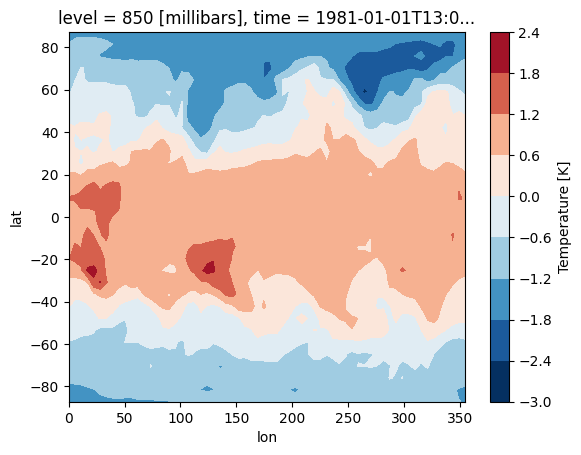

In [49]:
sample_input.plot.contourf()

create a copy of the xarray data arrray to reuse the metadata for plotting

In [50]:
float(wb_train_ds._ds_norm['temperature'].min()), float(wb_train_ds._ds_norm['temperature'].max()), float(wb_train_ds._ds_norm['temperature'].mean()), float(wb_train_ds._ds_norm['temperature'].std())

(-3.007214069366455,
 2.2304141521453857,
 -0.07885128259658813,
 0.9825160503387451)

(array([   5749.,  113843.,  364522.,  600267.,  767744.,  593567.,
         618591., 1303467.,  205133.,    4397.]),
 array([-3.00721407, -2.48345137, -1.95968843, -1.4359256 , -0.91216278,
        -0.38840008,  0.13536286,  0.6591258 ,  1.18288851,  1.70665121,
         2.23041415]),
 <BarContainer object of 10 artists>)

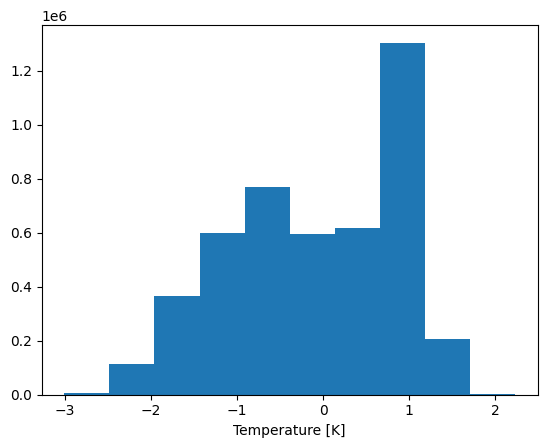

In [51]:
wb_train_ds._ds_norm['temperature'].plot.hist()

In [52]:
pred_da = xarray.DataArray(sample_input)

In [53]:
pred_da

<xarray.DataArray 'temperature' (lat: 32, lon: 64)> Size: 8kB
dask.array<getitem, shape=(32, 64), dtype=float32, chunksize=(32, 64), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    level    int32 4B 850
    time     datetime64[ns] 8B 1981-01-01T13:00:00
Attributes:
    units:          K
    long_name:      Temperature
    standard_name:  air_temperature

In [54]:
wb_val_ds[2]

tensor([[[-1.7950, -1.8043, -1.8171,  ..., -1.8159, -1.8054, -1.7966],
         [-1.5261, -1.6234, -1.7298,  ..., -1.4502, -1.4574, -1.4758],
         [-1.3123, -1.4431, -1.5983,  ..., -1.0468, -1.0978, -1.1847],
         ...,
         [-0.9707, -1.1449, -1.2130,  ..., -1.2500, -1.1177, -1.0170],
         [-1.1162, -1.1358, -1.1200,  ..., -1.2274, -1.1647, -1.0995],
         [-1.1730, -1.1635, -1.1577,  ..., -1.2147, -1.2025, -1.1870]],

        [[-2.1600, -2.1610, -2.1640,  ..., -2.1580, -2.1580, -2.1580],
         [-2.0831, -2.1080, -2.1360,  ..., -2.0481, -2.0561, -2.0661],
         [-1.8393, -1.8822, -1.9232,  ..., -1.8283, -1.8063, -1.8113],
         ...,
         [-0.7763, -0.8612, -0.9391,  ..., -0.7393, -0.7243, -0.7273],
         [-0.7213, -0.7473, -0.7683,  ..., -0.7283, -0.7103, -0.7063],
         [-0.7223, -0.7023, -0.6834,  ..., -0.7943, -0.7693, -0.7453]],

        [[-2.3782, -2.3305, -2.3171,  ..., -2.3849, -2.3919, -2.3958],
         [-1.5178, -1.6240, -1.7035,  ..., -1

In [55]:
pred_arr = ae_model.forward(wb_val_ds[2].to(device)).to('cpu').detach().numpy() 

In [56]:
pred_da.shape

(32, 64)

In [57]:
pred_arr.shape

(1, 6, 32, 64)

In [58]:
pred_da.values = pred_arr[0,0,:,:]

In [59]:
pred_arr.shape

(1, 6, 32, 64)

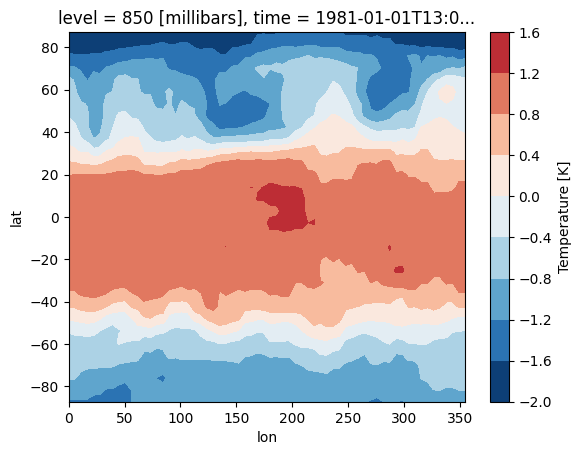

In [60]:
pred_da.plot.contourf()

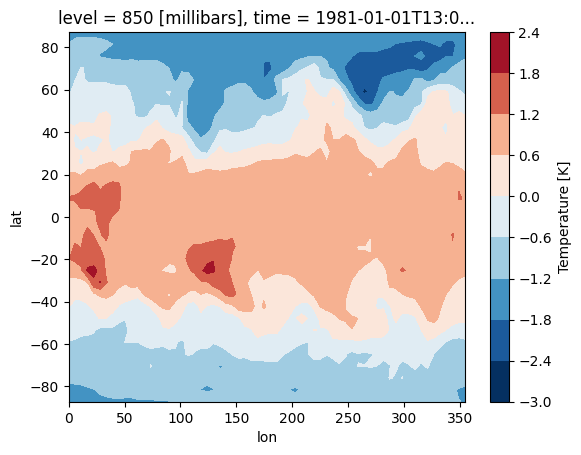

In [61]:
(wb_train_ds._ds_norm)['temperature'].sel(level=850, time='1981-01-01T13:00').plot.contourf()

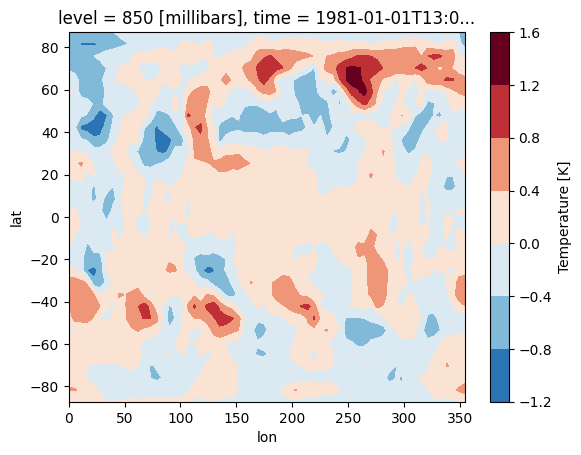

In [62]:
(pred_da - wb_train_ds._ds_norm)['temperature'].sel(level=850, time='1981-01-01T13:00').plot.contourf()